0:	learn: 1.0984246	test: 1.0982902	best: 1.0982902 (0)	total: 2.68s	remaining: 4m 25s
10:	learn: 0.5026337	test: 0.5023266	best: 0.5023266 (10)	total: 15.2s	remaining: 2m 3s
20:	learn: 0.3298137	test: 0.3294883	best: 0.3294883 (20)	total: 26.4s	remaining: 1m 39s
30:	learn: 0.2844199	test: 0.2841734	best: 0.2841734 (30)	total: 37s	remaining: 1m 22s
40:	learn: 0.2684998	test: 0.2683151	best: 0.2683151 (40)	total: 47.1s	remaining: 1m 7s
50:	learn: 0.2606245	test: 0.2604972	best: 0.2604972 (50)	total: 56.5s	remaining: 54.3s
60:	learn: 0.2550748	test: 0.2549678	best: 0.2549678 (60)	total: 1m 6s	remaining: 42.2s
70:	learn: 0.2512901	test: 0.2511985	best: 0.2511985 (70)	total: 1m 15s	remaining: 30.9s
80:	learn: 0.2482107	test: 0.2481311	best: 0.2481311 (80)	total: 1m 24s	remaining: 19.9s
90:	learn: 0.2451496	test: 0.2450597	best: 0.2450597 (90)	total: 1m 34s	remaining: 9.31s
99:	learn: 0.2424739	test: 0.2424298	best: 0.2424298 (99)	total: 1m 43s	remaining: 0us

bestTest = 0.2424297739
bestIt

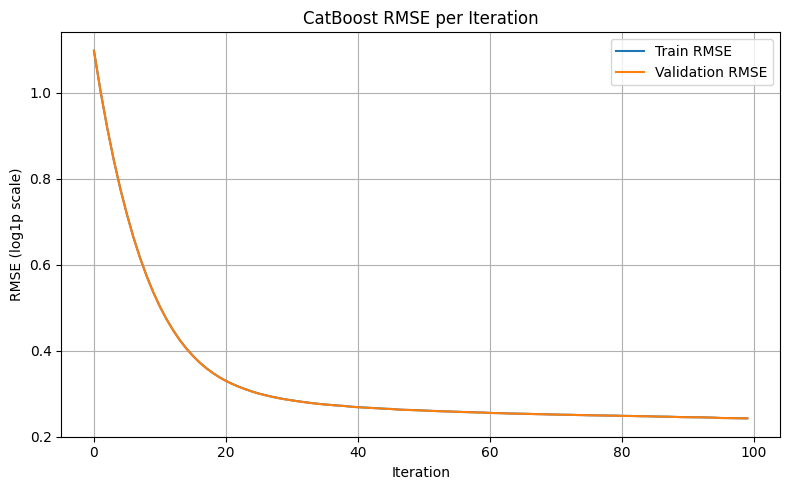

📌 [Weighted] 앙상블 MAE: 1.795064492973242
📌 [Weighted] 앙상블 R² : 0.9732069928427883


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# ========== 1. 데이터 불러오기 ==========
dfs = []
for year in [21, 22, 23]:
    df = pd.read_csv(f"C:/Users/user/Desktop/weather/weather/train_subway{year}_cleaned.csv", encoding='utf-8')
    df.columns = [
        'time', 'line', 'station_number', 'station_name', 'direction',
        'station_code', 'temperature', 'wind_direction', 'wind_speed',
        'rain_day', 'rain_hour', 'humidity', 'insolation', 'temp_chill', 'congestion'
    ]
    dfs.append(df)

df24 = pd.read_csv("C:/Users/user/Desktop/weather/weather/train_subway24_cleaned.csv", encoding='utf-8')
df24.rename(columns={
    'TM': 'time', 'Line': 'line', 'station_number': 'station_number',
    'station_name': 'station_name', 'Direction': 'direction',
    'STN': 'station_code', 'TA': 'temperature', 'WD': 'wind_direction',
    'WS': 'wind_speed', 'RN_DAY': 'rain_day', 'RN_HR1': 'rain_hour',
    'HM': 'humidity', 'SI': 'insolation', 'ta_chi': 'temp_chill',
    'Congestion': 'congestion'
}, inplace=True)

# ========== 2. 결측값 처리 ==========
def preprocess(df):
    df = df.copy()
    df.replace(-99, np.nan, inplace=True)
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].interpolate(method='linear', limit_direction='both')
    return df

df_train = pd.concat(dfs, ignore_index=True)
df_train = preprocess(df_train)
df24 = preprocess(df24)

# ========== 3. 시간 피처 추가 ==========
def add_time_features(df):
    df['hour'] = df['time'].astype(str).str[-2:].astype(int)
    df['weekday'] = pd.to_datetime(df['time'].astype(str), format='%Y%m%d%H').dt.weekday
    return df

df_train = add_time_features(df_train)
df24 = add_time_features(df24)

# ========== 4. 통계 기반 파생변수 ==========
station_mean = df_train.groupby('station_code')['congestion'].mean().to_dict()
hourly_mean = df_train.groupby(['station_code', 'hour'])['congestion'].mean().to_dict()

df_train['station_mean_cong'] = df_train['station_code'].map(station_mean)
df_train['station_hour_mean_cong'] = df_train.set_index(['station_code', 'hour']).index.map(hourly_mean)

df24['station_mean_cong'] = df24['station_code'].map(station_mean)
df24['station_hour_mean_cong'] = df24.set_index(['station_code', 'hour']).index.map(hourly_mean)

overall_mean = df_train['congestion'].mean()
df24['station_mean_cong'] = df24['station_mean_cong'].fillna(overall_mean)
df24['station_hour_mean_cong'] = df24['station_hour_mean_cong'].fillna(overall_mean)

# ========== 5. 변화량 기반 피처 ==========
def add_delta_features(df, is_train=True):
    df = df.sort_values(['station_code', 'time']).reset_index(drop=True)
    df['delta_temp'] = df.groupby('station_code')['temperature'].diff().fillna(0)
    if is_train:
        df['delta_congestion'] = df.groupby('station_code')['congestion'].diff().fillna(0)
        df['rolling_cong_mean_3'] = df.groupby('station_code')['congestion'].transform(lambda x: x.rolling(3, min_periods=1).mean())
    return df

df_train = add_delta_features(df_train, is_train=True)
df24 = add_delta_features(df24, is_train=False)
df24['delta_congestion'] = 0
df24['rolling_cong_mean_3'] = df24['station_mean_cong']

# ========== 6. 학습 데이터 준비 ==========
features = [
    'temperature', 'wind_direction', 'wind_speed',
    'rain_day', 'rain_hour', 'humidity', 'insolation',
    'temp_chill', 'hour', 'weekday',
    'station_mean_cong', 'station_hour_mean_cong',
    'delta_temp', 'delta_congestion', 'rolling_cong_mean_3'
]
X = df_train[features]
y = df_train['congestion']
y_log = np.log1p(y)

X_train, X_val, y_train_log, y_val_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# ========== 샘플 가중치 정의 ==========
high_threshold = np.log1p(100)
weights = (y_train_log > high_threshold).astype(float) * 4 + 1  # 혼잡도 100 이상 → 가중치 5

# ========== 7. 모델 정의 ==========
model_hist = HistGradientBoostingRegressor(
    random_state=42, max_leaf_nodes=64, min_samples_leaf=20
)
model_xgb = XGBRegressor(
    random_state=42, n_estimators=100, learning_rate=0.1, max_depth=6
)
model_cat = CatBoostRegressor(
    verbose=10, iterations=100, learning_rate=0.1, depth=6,
    random_seed=42, loss_function='RMSE'  # 손실함수 MAE 사용
)

# ========== 8. 학습 (가중치 적용) ==========
model_hist.fit(X_train, y_train_log, sample_weight=weights)
model_xgb.fit(X_train, y_train_log, sample_weight=weights)
model_cat.fit(X_train, y_train_log, eval_set=(X_val, y_val_log), use_best_model=False)


# ========== 9. 검증 ==========
val_pred_log = (model_hist.predict(X_val) + model_xgb.predict(X_val) + model_cat.predict(X_val)) / 3
val_pred = np.expm1(val_pred_log)
y_val_real = np.expm1(y_val_log)

print("📌 [Weighted] 앙상블 MAE:", mean_absolute_error(y_val_real, val_pred))
print("📌 [Weighted] 앙상블 R² :", r2_score(y_val_real, val_pred))

# ========== 10. 예측 및 정수화 ==========
X_test = df24[features]
pred_log = (model_hist.predict(X_test) + model_xgb.predict(X_test) + model_cat.predict(X_test)) / 3
pred_real = np.expm1(pred_log)
pred_int = np.rint(pred_real).clip(0, 300)

df24['predicted_congestion'] = pred_int.astype(int)

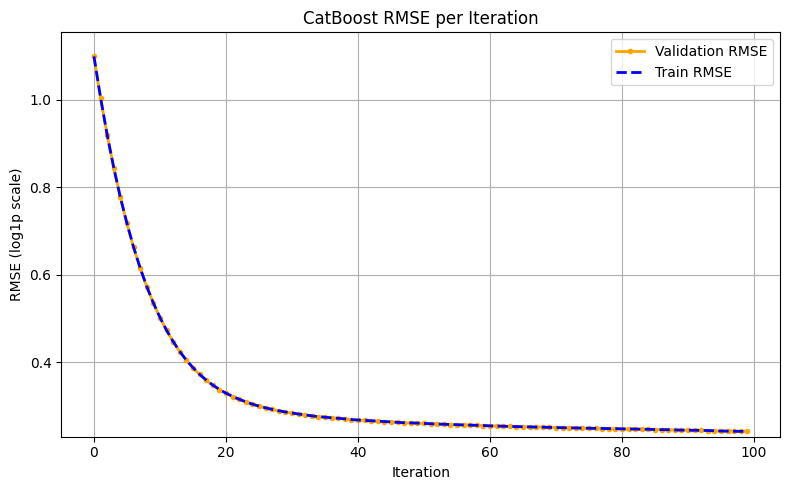

In [10]:
evals_result = model_cat.get_evals_result()

train_rmse = evals_result['learn']['RMSE']
val_rmse = evals_result['validation']['RMSE']
iterations = range(len(train_rmse))

plt.figure(figsize=(8, 5))

plt.plot(iterations, val_rmse, label='Validation RMSE', linestyle='-', color='orange', marker='o', markersize=3, linewidth=2)
plt.plot(iterations, train_rmse, label='Train RMSE', linestyle='--', color='blue', linewidth=2)


# y축 확대 → 작은 차이도 드러나도록
plt.ylim(min(min(train_rmse), min(val_rmse)) * 0.95, max(max(train_rmse), max(val_rmse)) * 1.05)

plt.title("CatBoost RMSE per Iteration")
plt.xlabel("Iteration")
plt.ylabel("RMSE (log1p scale)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [13]:
val_rmse = model_cat.get_evals_result()['validation']['RMSE']
avg_all = np.mean(val_rmse)
avg_excl_top5 = np.mean(val_rmse[5:])

print("전체 평균 RMSE:", avg_all)
print("상위 5개 제외한 평균 RMSE:", avg_excl_top5)


전체 평균 RMSE: 0.3276959720562352
상위 5개 제외한 평균 RMSE: 0.2960705200854869


In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(evals_result['learn']['MAE'], label='Train MAE')
plt.plot(evals_result['validation']['MAE'], label='Val MAE')
plt.title("CatBoost MAE per Iteration (log1p scale)")
plt.xlabel("Iteration")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [5]:
from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(y_val_real, val_pred)
rmse = np.sqrt(mse)
print("MSE:", mse)
print("RMSE:", rmse)


MSE: 9.923224896004852
RMSE: 3.150115060756488


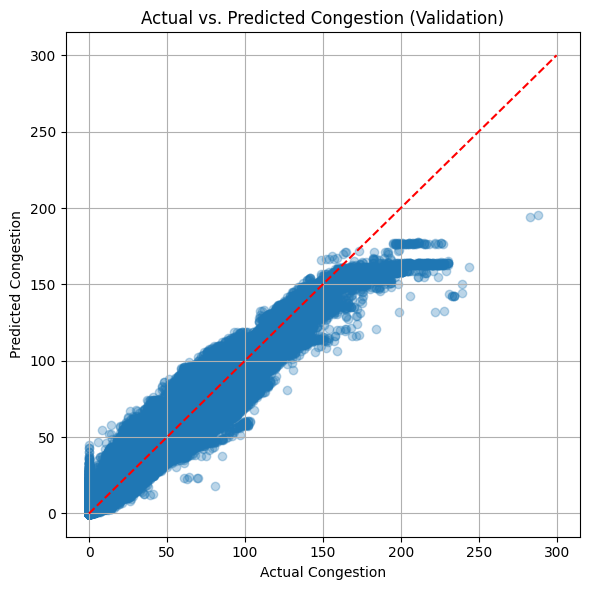

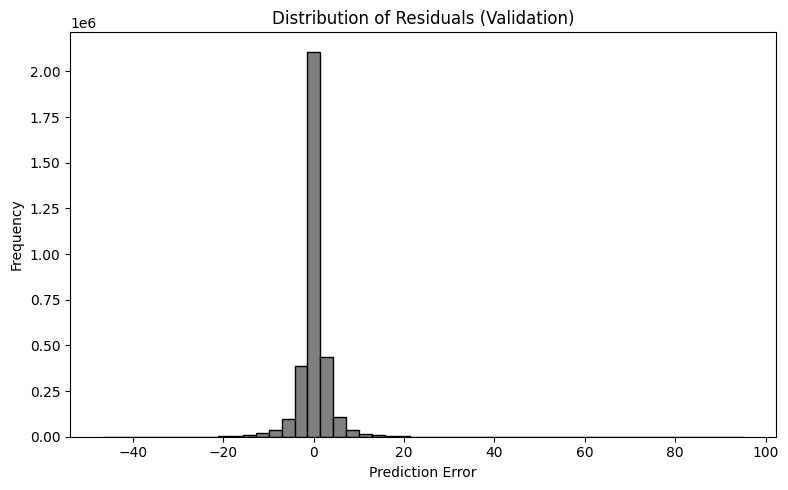

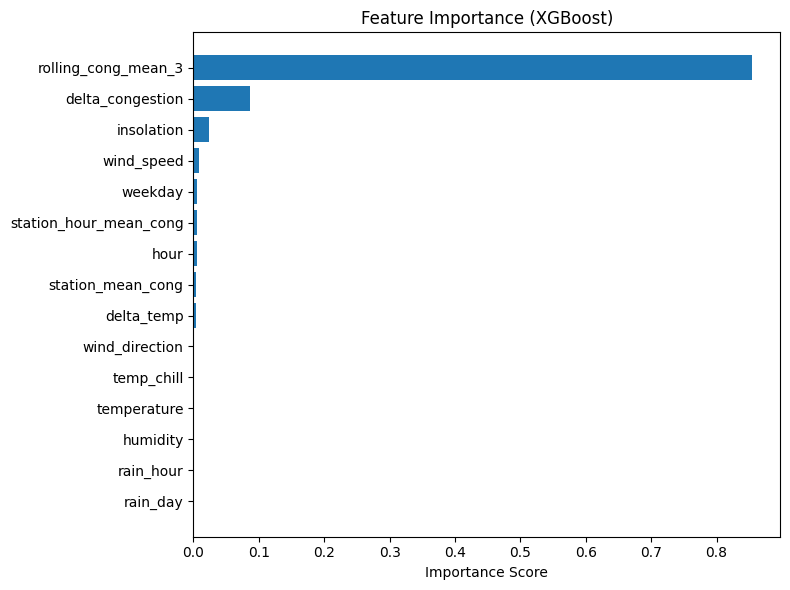

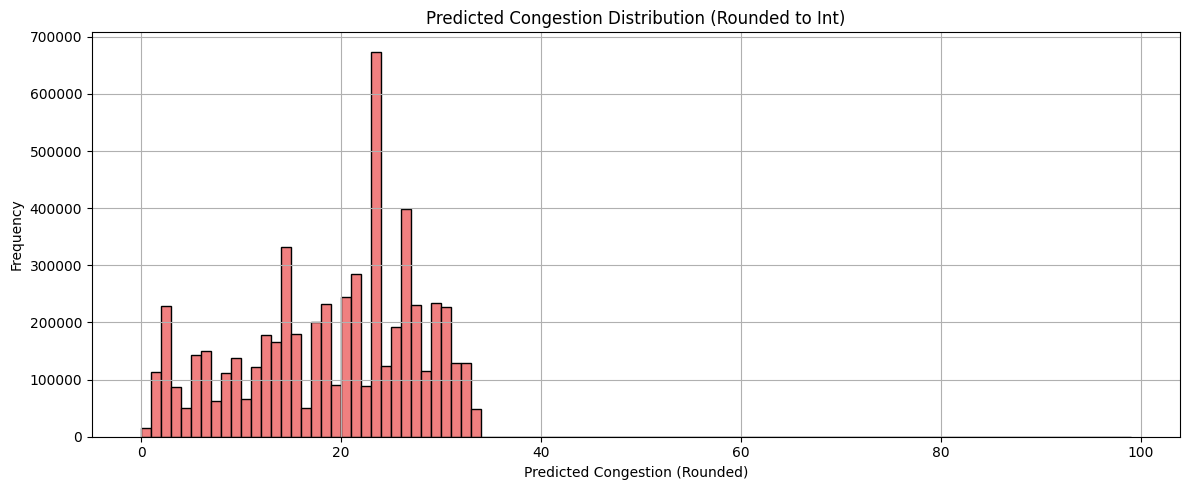

In [2]:
# 예측값과 실제값의 분포 비교, 정확도 직관적 확인
plt.figure(figsize=(6, 6))
plt.scatter(y_val_real, val_pred, alpha=0.3)
plt.plot([0, 300], [0, 300], 'r--')
plt.title("Actual vs. Predicted Congestion (Validation)")
plt.xlabel("Actual Congestion")
plt.ylabel("Predicted Congestion")
plt.grid(True)
plt.tight_layout()
plt.show()

# 잔차의 분포 확인 (편향 여부, 예측 불안정성 진단)
residuals = y_val_real - val_pred
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=50, color='gray', edgecolor='black')
plt.title("Distribution of Residuals (Validation)")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Feature Importance (예: XGBoost 기준) - 모델이 어떤 feature를 더 많이 사용했는지 시각적으로 분석
importances = model_xgb.feature_importances_
feature_names = X_train.columns
sorted_idx = np.argsort(importances)

plt.figure(figsize=(8, 6))
plt.barh(range(len(importances)), importances[sorted_idx], align='center')
plt.yticks(range(len(importances)), [feature_names[i] for i in sorted_idx])
plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

# 정수화된 예측값 분포 (0~300 범위로 클리핑됨)
plt.figure(figsize=(12, 5))
plt.hist(pred_int, bins=range(0, 100), color='lightcoral', edgecolor='black')
plt.title("Predicted Congestion Distribution (Rounded to Int)")
plt.xlabel("Predicted Congestion (Rounded)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

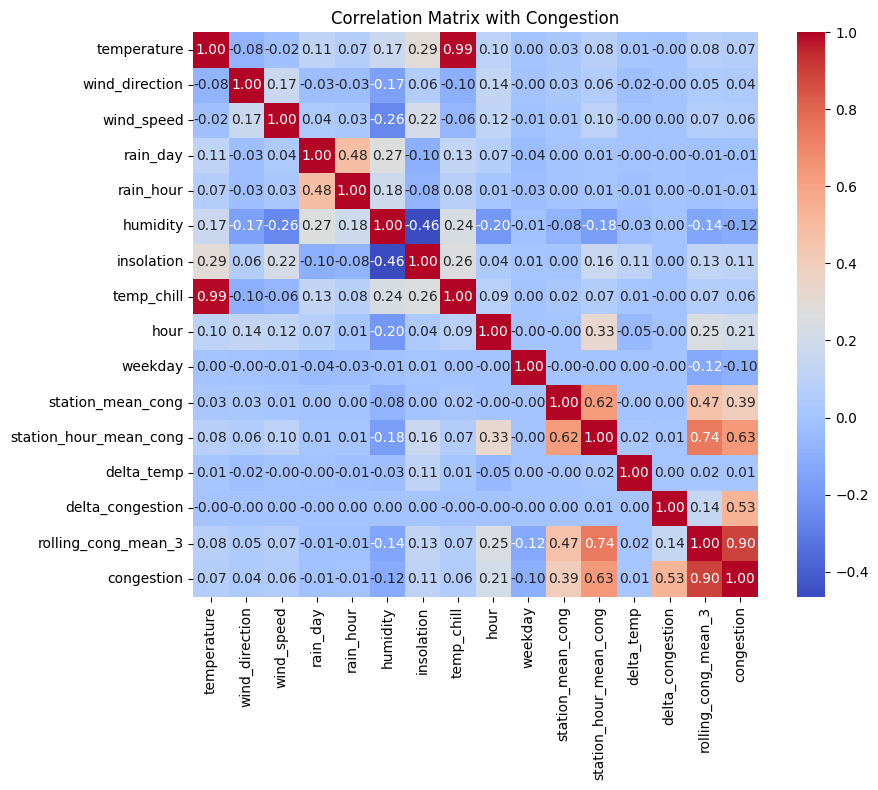

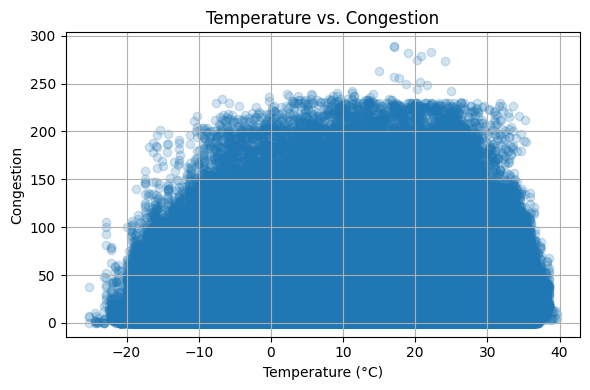

In [ ]:
import seaborn as sns

# 5. Correlation Heatmap (전체 변수 간 상관관계)
# 목적: 기상 변수와 지하철 혼잡도(congestion) 간 선형적 상관관계 시각화
# 활용 포인트: 특정 날씨 요소가 혼잡도에 얼마나 영향을 주는지 직관적으로 파악 가능 (양의 상관계수 → 해당 기상 요인이 커질수록 혼잡도 증가)
# 사용할 열만 선택 (congestion 포함)
corr_features = features + ['congestion']
df_corr = df_train[corr_features].copy()

plt.figure(figsize=(10, 8))
corr = df_corr.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Correlation Matrix with Congestion")
plt.tight_layout()
plt.show()

# 6. Scatter Plot (혼잡도 vs. 기상 요소 개별 확인)
# 목적: 혼잡도와 특정 기상 변수 간 관계 형태 확인 (선형 / 비선형 여부 등)
plt.figure(figsize=(6, 4))
plt.scatter(df_train['temperature'], df_train['congestion'], alpha=0.2)
plt.title("Temperature vs. Congestion")
plt.xlabel("Temperature (°C)")
plt.ylabel("Congestion")
plt.grid(True)
plt.tight_layout()
plt.show()